# SwinV2 Linear Probe Baseline — 5-Fold Cross-Validation

Frozen SwinV2 features + Logistic Regression — no neural network training involved. This is a **linear probe** baseline: we fit a simple sklearn classifier on frozen pretrained features to measure how much useful information the representations already carry.

**Protocol:** Hold out 10% test set → extract features once (frozen backbone) → 5-fold CV on remaining 90% → each fold: StandardScaler + LogisticRegression → evaluate all folds on shared test set → ensemble by averaging predicted probabilities.

We test SwinV2-Base and SwinV2-Tiny.

**Important:** SwinV2 uses **256x256** input resolution (not 224x224 like DINOv2).

**Binary labels:**
| Original Class | Binary Label |
|---|---|
| Melanoma | **Malignant** (1) |
| BCC | **Malignant** (1) |
| SCC | **Malignant** (1) |
| Actinic Keratosis | **Malignant** (1) |
| Malignant_Other | **Malignant** (1) |
| Melanocytic_Nevus | **Benign** (0) |
| Seborrheic_Keratosis | **Benign** (0) |
| Dermatofibroma | **Benign** (0) |
| Hemangioma | **Benign** (0) |
| Fibrous_Papule | **Benign** (0) |
| Other_Benign | **Benign** (0) |

## 1. Setup & Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, precision_recall_fscore_support, fbeta_score
)
from sklearn.preprocessing import StandardScaler

from transformers import Swinv2Model

from utils import (
    BinaryDermoscopeSkinDataset, get_transforms, BINARY_MAP, CLASS_NAMES,
    find_optimal_threshold, compute_metrics, MIN_SENSITIVITY_TARGET
)

In [35]:
# ── Configuration ──
IMAGES_DIR = "../DataCleaning/Images"
MANIFEST_PATH = "../DataCleaning/instances.csv"
BATCH_SIZE = 32  # Larger batch for feature extraction (no backprop)
NUM_CLASSES = 2
SEED = 42
K_FOLDS = 5

# SwinV2 uses 256x256 input (not 224x224)
IMAGE_SIZE = 256
RESIZE_SIZE = 288

# Logistic regression config
LR_MAX_ITER = 1000
LR_C = 1.0
LR_CLASS_WEIGHT = 'balanced'

NUM_WORKERS = 0 if os.name == "nt" else min(os.cpu_count() or 8, 12)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"\nLINEAR PROBE BASELINE — {K_FOLDS}-FOLD CROSS-VALIDATION")
print(f"  Frozen SwinV2 features + Logistic Regression")
print(f"  {K_FOLDS} folds, ensemble by averaging probabilities")
print(f"  Compare: SwinV2-Base, Tiny")
print(f"  Input size: {IMAGE_SIZE}x{IMAGE_SIZE}")

if torch.cuda.is_available():
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using: cuda
PyTorch: 2.5.1+cu121

LINEAR PROBE BASELINE — 5-FOLD CROSS-VALIDATION
  Frozen SwinV2 features + Logistic Regression
  5 folds, ensemble by averaging probabilities
  Compare: SwinV2-Base, Tiny
  Input size: 256x256

GPU: NVIDIA GeForce RTX 4060
GPU Memory: 8.6 GB


## 2. Transforms (No Augmentation)

SwinV2 models expect 256x256 input images.

In [36]:
_, eval_transform = get_transforms(image_size=IMAGE_SIZE, resize_size=RESIZE_SIZE)

print(f"Transform created (center crop to {IMAGE_SIZE}x{IMAGE_SIZE}, no augmentation)")

Transform created (center crop to 256x256, no augmentation)


## 3. Load Data & Test Holdout

In [37]:
manifest = pd.read_csv(MANIFEST_PATH)
print(f"Total instances: {len(manifest)}")
print(f"\nOriginal class distribution:")
print(manifest["cancer_type"].value_counts())

print(f"\nBinary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(manifest)
    print(f"  {name} ({lbl}): {count} ({pct:.1f}%)")

# 10% test holdout (same seed as fine-tuning experiments)
sss_test = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
trainval_idx, test_idx = next(sss_test.split(manifest, manifest["binary_label"]))

trainval_manifest = manifest.iloc[trainval_idx].reset_index(drop=True)
test_manifest = manifest.iloc[test_idx].reset_index(drop=True)

print(f"\nStratified split: TrainVal {len(trainval_manifest)} | Test {len(test_manifest)}")

print(f"\nTrainVal binary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (trainval_manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(trainval_manifest)
    print(f"  {name}: {count} ({pct:.1f}%)")

print(f"\nTest binary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (test_manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(test_manifest)
    print(f"  {name}: {count} ({pct:.1f}%)")

Total instances: 906

Original class distribution:
cancer_type
BCC                     200
Melanocytic_Nevus       190
Other_Benign            138
SCC                     123
Seborrheic_Keratosis     79
Melanoma                 77
Actinic_Keratosis        63
Dermatofibroma           16
Hemangioma               10
Fibrous_Papule            6
Malignant_Other           4
Name: count, dtype: int64

Binary distribution:
  Benign (0): 439 (48.5%)
  Malignant (1): 467 (51.5%)

Stratified split: TrainVal 815 | Test 91

TrainVal binary distribution:
  Benign: 395 (48.5%)
  Malignant: 420 (51.5%)

Test binary distribution:
  Benign: 44 (48.4%)
  Malignant: 47 (51.6%)


## 4. Create Datasets & Loaders

In [38]:
trainval_dataset = BinaryDermoscopeSkinDataset(trainval_manifest, IMAGES_DIR, transform=eval_transform)
test_dataset = BinaryDermoscopeSkinDataset(test_manifest, IMAGES_DIR, transform=eval_transform)

loader_kwargs = {'num_workers': NUM_WORKERS, 'pin_memory': True} if torch.cuda.is_available() else {}
trainval_loader = DataLoader(trainval_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print(f"Datasets: TrainVal {len(trainval_dataset)} | Test {len(test_dataset)}")
print(f"Batches:  TrainVal {len(trainval_loader)} | Test {len(test_loader)}")

Datasets: TrainVal 822 | Test 91
Batches:  TrainVal 26 | Test 3


## 5. Instance-to-Sample Mapping (for KFold)

In [39]:
# Build instance → sample index mapping for KFold splitting
# Each manifest row may have multiple dermoscope images (split by ";")
instance_to_samples = []
idx = 0
for _, row in trainval_manifest.iterrows():
    n_files = len(str(row["dscope_files"]).split(";"))
    instance_to_samples.append(list(range(idx, idx + n_files)))
    idx += n_files

print(f"Instance-to-sample mapping: {len(instance_to_samples)} instances -> {idx} samples")

Instance-to-sample mapping: 815 instances -> 822 samples


## 6. Load SwinV2 Backbones (Base & Tiny)

In [40]:
swinv2_base = Swinv2Model.from_pretrained(
    "microsoft/swinv2-base-patch4-window16-256",
    use_safetensors=True
)
swinv2_tiny = Swinv2Model.from_pretrained(
    "microsoft/swinv2-tiny-patch4-window16-256",
    use_safetensors=True
)

for model in [swinv2_base, swinv2_tiny]:
    model.to(DEVICE).eval()
    for param in model.parameters():
        param.requires_grad = False

embed_dim_base = swinv2_base.config.hidden_size
embed_dim_tiny = swinv2_tiny.config.hidden_size

print(f"\n✓ SwinV2-Base  (patch4-window16-256): embed_dim={embed_dim_base}")
print(f"✓ SwinV2-Tiny  (patch4-window8-256): embed_dim={embed_dim_tiny}")
print(f"\nAll backbones frozen - feature extraction only")

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Swinv2Model LOAD REPORT from: microsoft/swinv2-base-patch4-window16-256
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/243 [00:00<?, ?it/s]

Swinv2Model LOAD REPORT from: microsoft/swinv2-tiny-patch4-window16-256
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✓ SwinV2-Base  (patch4-window16-256): embed_dim=768
✓ SwinV2-Tiny  (patch4-window8-256): embed_dim=768

All backbones frozen - feature extraction only


## 7. Feature Extraction Function

In [41]:
def extract_features(model, dataloader, desc="Extracting features"):
    """Extract frozen SwinV2 pooled features from dataloader."""
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc=desc):
            imgs = imgs.to(DEVICE, non_blocking=True)
            outputs = model(imgs)
            # Use pooler_output for SwinV2
            feats = outputs.pooler_output
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.vstack(all_features), np.concatenate(all_labels)

print("Feature extraction function defined.")

Feature extraction function defined.


## 8. Extract Features (Once Per Model)

Since backbones are frozen, features are deterministic — we extract once and reuse across all folds.

In [42]:
print("Extracting features from all models...\n")

# Base
base_tv_feats, tv_labels = extract_features(swinv2_base, trainval_loader, "Base: TrainVal")
base_test_feats, test_labels = extract_features(swinv2_base, test_loader, "Base: Test")
print(f"  Base TrainVal: {base_tv_feats.shape} | Test: {base_test_feats.shape}")

# Tiny
tiny_tv_feats, _ = extract_features(swinv2_tiny, trainval_loader, "Tiny: TrainVal")
tiny_test_feats, _ = extract_features(swinv2_tiny, test_loader, "Tiny: Test")
print(f"  Tiny TrainVal: {tiny_tv_feats.shape} | Test: {tiny_test_feats.shape}")

print(f"\n All features extracted. Labels shape: {tv_labels.shape}")

Extracting features from all models...



Base: TrainVal:   0%|          | 0/26 [00:00<?, ?it/s]

Base: Test:   0%|          | 0/3 [00:00<?, ?it/s]

  Base TrainVal: (822, 1024) | Test: (91, 1024)


Tiny: TrainVal:   0%|          | 0/26 [00:00<?, ?it/s]

Tiny: Test:   0%|          | 0/3 [00:00<?, ?it/s]

  Tiny TrainVal: (822, 768) | Test: (91, 768)

 All features extracted. Labels shape: (822,)


## 9. Evaluation Utilities

In [53]:
def binary_model_evaluation(y_true, y_probs, class_names, title="",
                           threshold=None, min_sensitivity=MIN_SENSITIVITY_TARGET):
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    if threshold is None:
        threshold, opt_sens, opt_spec = find_optimal_threshold(
            y_true, y_probs, min_sensitivity=min_sensitivity
        )
        print(f"\n\U0001F3AF Optimal threshold for \u2265{min_sensitivity*100:.0f}% sensitivity: {threshold:.3f}")
        print(f"   At this threshold: Sensitivity={opt_sens:.4f}, Specificity={opt_spec:.4f}")
    y_pred = (y_probs >= threshold).astype(int)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    f2 = fbeta_score(y_true, y_pred, beta=2, average='binary', zero_division=0)
    accuracy = np.mean(y_true == y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    auc_roc = roc_auc_score(y_true, y_probs)
    auc_pr = average_precision_score(y_true, y_probs)
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    print(f"  Classification Threshold: {threshold:.3f}")
    print(f"\n  SENSITIVITY METRICS (Malignant Detection):")
    print(f"    Sensitivity (Recall):  {sensitivity:.4f} {'✓' if sensitivity >= min_sensitivity else '✗'}")
    print(f"    PPV (Precision):       {ppv:.4f}")
    print(f"    F2 Score:              {f2:.4f}")
    print(f"\n  OVERALL METRICS:")
    print(f"    Accuracy:              {accuracy:.4f}")
    print(f"    Specificity:           {specificity:.4f}")
    print(f"    NPV:                   {npv:.4f}")
    print(f"    F1 Score:              {f1:.4f}")
    print(f"    AUC-ROC:               {auc_roc:.4f}")
    print(f"    AUC-PR:                {auc_pr:.4f}")
    print(f"{'='*70}")
    print(f"\n  Confusion Matrix:")
    print(f"    TN={tn:<4} FP={fp:<4}")
    print(f"    FN={fn:<4} TP={tp:<4}")
    print(f"\n{classification_report(y_true, y_pred, target_names=class_names)}")
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title(f"Confusion Matrix\nThreshold={threshold:.3f}")
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    axes[1].plot(fpr, tpr, lw=2, color='darkorange', label=f'ROC (AUC = {auc_roc:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    y_pred_op = (y_probs >= threshold).astype(int)
    tn_op, fp_op, fn_op, tp_op = confusion_matrix(y_true, y_pred_op).ravel()
    fpr_op = fp_op / (fp_op + tn_op) if (fp_op + tn_op) > 0 else 0
    tpr_op = tp_op / (tp_op + fn_op) if (tp_op + fn_op) > 0 else 0
    axes[1].plot(fpr_op, tpr_op, 'ro', markersize=10,
                label=f'Operating Point\n(Sens={tpr_op:.3f})')
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_probs)
    axes[2].plot(rec_curve, prec_curve, lw=2, color='green', label=f'PR (AP = {auc_pr:.4f})')
    axes[2].plot(tpr_op, ppv, 'ro', markersize=10,
                label=f'Operating Point\n(Rec={tpr_op:.3f}, Prec={ppv:.3f})')
    axes[2].set_xlabel("Recall (Sensitivity)")
    axes[2].set_ylabel("Precision (PPV)")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend(loc="best")
    axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return {
        "threshold": threshold, "accuracy": accuracy, "precision": precision,
        "recall": recall, "sensitivity": sensitivity, "specificity": specificity,
        "ppv": ppv, "npv": npv, "f1": f1, "f2": f2,
        "auc_roc": auc_roc, "auc_pr": auc_pr,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
    }

## 10. 5-Fold CV — SwinV2-Base

In [54]:
print(f"\n{'='*70}")
print(f"  SwinV2-BASE — {K_FOLDS}-Fold Cross-Validation")
print(f"{'='*70}")

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

base_fold_val_metrics = []
base_fold_test_probs = []

for fold, (train_inst_idx, val_inst_idx) in enumerate(skf.split(trainval_manifest, trainval_manifest["binary_label"])):
    print(f"\n--- Fold {fold+1}/{K_FOLDS} ---")

    # Map instance indices to sample (image) indices
    train_samp_idx = [i for inst in train_inst_idx for i in instance_to_samples[inst]]
    val_samp_idx = [i for inst in val_inst_idx for i in instance_to_samples[inst]]

    fold_train_feats = base_tv_feats[train_samp_idx]
    fold_train_labels = tv_labels[train_samp_idx]
    fold_val_feats = base_tv_feats[val_samp_idx]
    fold_val_labels = tv_labels[val_samp_idx]

    print(f"  Train: {len(train_samp_idx)} samples | Val: {len(val_samp_idx)} samples")

    # StandardScaler
    scaler = StandardScaler()
    fold_train_scaled = scaler.fit_transform(fold_train_feats)
    fold_val_scaled = scaler.transform(fold_val_feats)
    fold_test_scaled = scaler.transform(base_test_feats)

    # Logistic Regression
    lr = LogisticRegression(
        max_iter=LR_MAX_ITER, C=LR_C, class_weight=LR_CLASS_WEIGHT,
        random_state=SEED, solver='lbfgs', verbose=0
    )
    lr.fit(fold_train_scaled, fold_train_labels)

    # Val metrics at optimal threshold
    val_probs = lr.predict_proba(fold_val_scaled)[:, 1]
    val_auc = roc_auc_score(fold_val_labels, val_probs)
    opt_thresh, opt_sens, opt_spec = find_optimal_threshold(fold_val_labels, val_probs, MIN_SENSITIVITY_TARGET)
    val_pred = (val_probs >= opt_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(fold_val_labels, val_pred).ravel()
    val_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    val_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    val_acc = np.mean(fold_val_labels == val_pred)
    val_f2 = fbeta_score(fold_val_labels, val_pred, beta=2, average='binary', zero_division=0)

    base_fold_val_metrics.append({
        'fold': fold + 1, 'threshold': opt_thresh, 'auc_roc': val_auc,
        'sensitivity': val_sens, 'specificity': val_spec, 'accuracy': val_acc, 'f2': val_f2
    })

    # Test predictions
    test_probs = lr.predict_proba(fold_test_scaled)[:, 1]
    base_fold_test_probs.append(test_probs)

    print(f"  Opt Thresh={opt_thresh:.3f} | Val AUC={val_auc:.4f} | Sens={val_sens:.4f} | Spec={val_spec:.4f} | Acc={val_acc:.4f} | F2={val_f2:.4f}")

# Fold summary
fold_df = pd.DataFrame(base_fold_val_metrics)
print(f"\n{'='*70}")
print("BASE — Per-Fold Validation Results (at optimal threshold):")
print(fold_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f"\nMean \u00b1 Std:")
for col in ['auc_roc', 'sensitivity', 'specificity', 'accuracy', 'f2']:
    vals = fold_df[col]
    print(f"  {col}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")


  SwinV2-BASE — 5-Fold Cross-Validation

--- Fold 1/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.7095 | Sens=0.8095 | Spec=0.4125 | Acc=0.6159 | F2=0.7539

--- Fold 2/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.6883 | Sens=0.8941 | Spec=0.3291 | Acc=0.6220 | F2=0.8102

--- Fold 3/5 ---
  Train: 657 samples | Val: 165 samples
  Opt Thresh=0.050 | Val AUC=0.7325 | Sens=0.7882 | Spec=0.4750 | Acc=0.6364 | F2=0.7461

--- Fold 4/5 ---
  Train: 657 samples | Val: 165 samples
  Opt Thresh=0.050 | Val AUC=0.7312 | Sens=0.8721 | Spec=0.4304 | Acc=0.6606 | F2=0.8082

--- Fold 5/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.6780 | Sens=0.8471 | Spec=0.4304 | Acc=0.6463 | F2=0.7877

BASE — Per-Fold Validation Results (at optimal threshold):
 fold  threshold  auc_roc  sensitivity  specificity  accuracy     f2
    1     0.0500   0.7095       0.8095       0.4125    0.6159 0.7539
    2     0.0500   0.6883 

## 11. Base — Ensemble Test Evaluation


Ensemble of 5 folds — evaluating on held-out test set...

🎯 Optimal threshold for ≥95% sensitivity: 0.050
   At this threshold: Sensitivity=0.9362, Specificity=0.1591

  SwinV2-Base (patch4-window8-256) Linear Probe — Ensemble Test
  Classification Threshold: 0.050

  SENSITIVITY METRICS (Malignant Detection):
    Sensitivity (Recall):  0.9362 ✗
    PPV (Precision):       0.5432
    F2 Score:              0.8178

  OVERALL METRICS:
    Accuracy:              0.5604
    Specificity:           0.1591
    NPV:                   0.7000
    F1 Score:              0.6875
    AUC-ROC:               0.5832
    AUC-PR:                0.5908

  Confusion Matrix:
    TN=7    FP=37  
    FN=3    TP=44  

              precision    recall  f1-score   support

      Benign       0.70      0.16      0.26        44
   Malignant       0.54      0.94      0.69        47

    accuracy                           0.56        91
   macro avg       0.62      0.55      0.47        91
weighted avg       0.62  

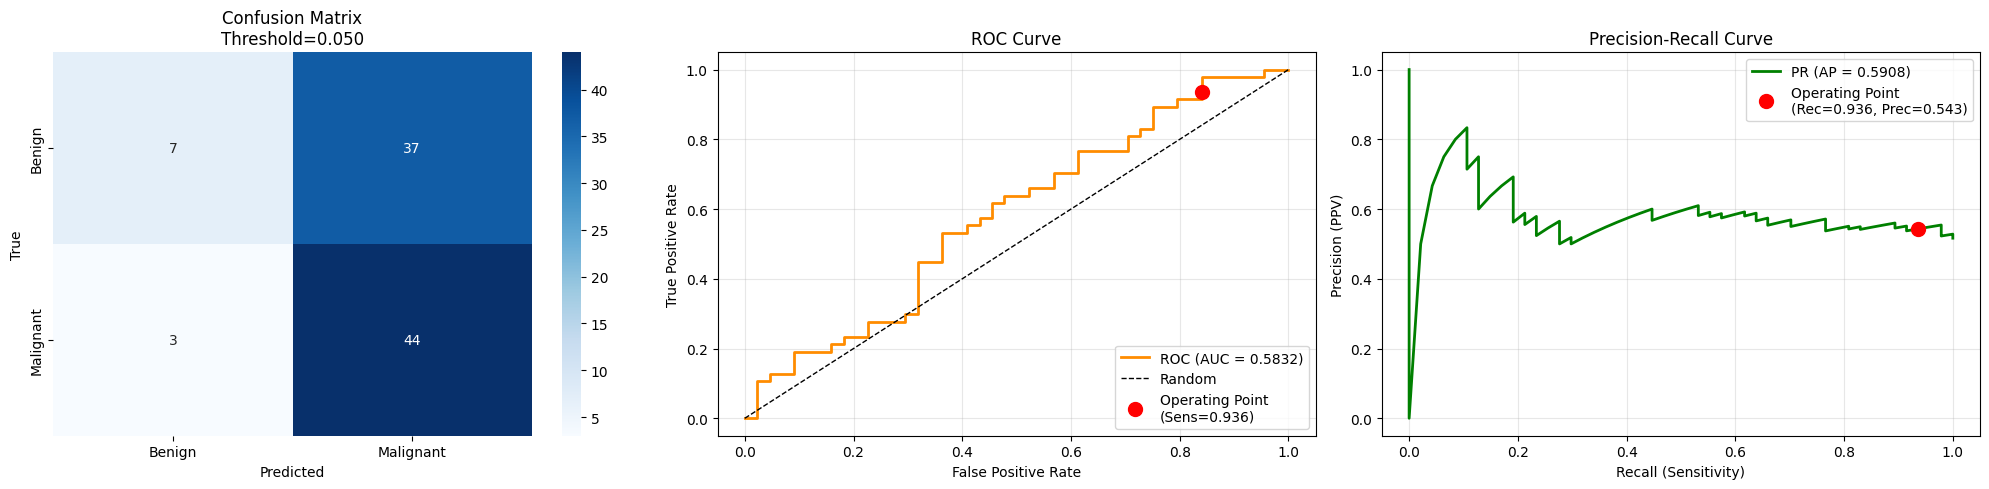

In [55]:
print(f"\nEnsemble of {K_FOLDS} folds — evaluating on held-out test set...")

# Average probabilities across folds
base_ensemble_probs = np.mean(base_fold_test_probs, axis=0)

base_test_metrics = binary_model_evaluation(
    test_labels, base_ensemble_probs, CLASS_NAMES,
    title="SwinV2-Base (patch4-window8-256) Linear Probe — Ensemble Test",
    min_sensitivity=MIN_SENSITIVITY_TARGET
)

## 12. 5-Fold CV — SwinV2-Tiny

In [56]:
print(f"\n{'='*70}")
print(f"  SwinV2-TINY — {K_FOLDS}-Fold Cross-Validation")
print(f"{'='*70}")

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

tiny_fold_val_metrics = []
tiny_fold_test_probs = []

for fold, (train_inst_idx, val_inst_idx) in enumerate(skf.split(trainval_manifest, trainval_manifest["binary_label"])):
    print(f"\n--- Fold {fold+1}/{K_FOLDS} ---")

    # Map instance indices to sample (image) indices
    train_samp_idx = [i for inst in train_inst_idx for i in instance_to_samples[inst]]
    val_samp_idx = [i for inst in val_inst_idx for i in instance_to_samples[inst]]

    fold_train_feats = tiny_tv_feats[train_samp_idx]
    fold_train_labels = tv_labels[train_samp_idx]
    fold_val_feats = tiny_tv_feats[val_samp_idx]
    fold_val_labels = tv_labels[val_samp_idx]

    print(f"  Train: {len(train_samp_idx)} samples | Val: {len(val_samp_idx)} samples")

    # StandardScaler
    scaler = StandardScaler()
    fold_train_scaled = scaler.fit_transform(fold_train_feats)
    fold_val_scaled = scaler.transform(fold_val_feats)
    fold_test_scaled = scaler.transform(tiny_test_feats)

    # Logistic Regression
    lr = LogisticRegression(
        max_iter=LR_MAX_ITER, C=LR_C, class_weight=LR_CLASS_WEIGHT,
        random_state=SEED, solver='lbfgs', verbose=0
    )
    lr.fit(fold_train_scaled, fold_train_labels)

    # Val metrics at optimal threshold
    val_probs = lr.predict_proba(fold_val_scaled)[:, 1]
    val_auc = roc_auc_score(fold_val_labels, val_probs)
    opt_thresh, opt_sens, opt_spec = find_optimal_threshold(fold_val_labels, val_probs, MIN_SENSITIVITY_TARGET)
    val_pred = (val_probs >= opt_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(fold_val_labels, val_pred).ravel()
    val_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    val_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    val_acc = np.mean(fold_val_labels == val_pred)
    val_f2 = fbeta_score(fold_val_labels, val_pred, beta=2, average='binary', zero_division=0)

    tiny_fold_val_metrics.append({
        'fold': fold + 1, 'threshold': opt_thresh, 'auc_roc': val_auc,
        'sensitivity': val_sens, 'specificity': val_spec, 'accuracy': val_acc, 'f2': val_f2
    })

    # Test predictions
    test_probs = lr.predict_proba(fold_test_scaled)[:, 1]
    tiny_fold_test_probs.append(test_probs)

    print(f"  Opt Thresh={opt_thresh:.3f} | Val AUC={val_auc:.4f} | Sens={val_sens:.4f} | Spec={val_spec:.4f} | Acc={val_acc:.4f} | F2={val_f2:.4f}")

# Fold summary
fold_df = pd.DataFrame(tiny_fold_val_metrics)
print(f"\n{'='*70}")
print("TINY — Per-Fold Validation Results (at optimal threshold):")
print(fold_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f"\nMean \u00b1 Std:")
for col in ['auc_roc', 'sensitivity', 'specificity', 'accuracy', 'f2']:
    vals = fold_df[col]
    print(f"  {col}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")


  SwinV2-TINY — 5-Fold Cross-Validation

--- Fold 1/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.7411 | Sens=0.8333 | Spec=0.5000 | Acc=0.6707 | F2=0.7848

--- Fold 2/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.6588 | Sens=0.8941 | Spec=0.3165 | Acc=0.6159 | F2=0.8085

--- Fold 3/5 ---
  Train: 657 samples | Val: 165 samples
  Opt Thresh=0.050 | Val AUC=0.7109 | Sens=0.7882 | Spec=0.4375 | Acc=0.6182 | F2=0.7412

--- Fold 4/5 ---
  Train: 657 samples | Val: 165 samples
  Opt Thresh=0.050 | Val AUC=0.7538 | Sens=0.8953 | Spec=0.4177 | Acc=0.6667 | F2=0.8244

--- Fold 5/5 ---
  Train: 658 samples | Val: 164 samples
  Opt Thresh=0.050 | Val AUC=0.7178 | Sens=0.7529 | Spec=0.4557 | Acc=0.6098 | F2=0.7159

TINY — Per-Fold Validation Results (at optimal threshold):
 fold  threshold  auc_roc  sensitivity  specificity  accuracy     f2
    1     0.0500   0.7411       0.8333       0.5000    0.6707 0.7848
    2     0.0500   0.6588 

## 13. Tiny — Ensemble Test Evaluation


Ensemble of 5 folds — evaluating on held-out test set...

🎯 Optimal threshold for ≥95% sensitivity: 0.050
   At this threshold: Sensitivity=0.8936, Specificity=0.2955

  SwinV2-Tiny (patch4-window8-256) Linear Probe — Ensemble Test
  Classification Threshold: 0.050

  SENSITIVITY METRICS (Malignant Detection):
    Sensitivity (Recall):  0.8936 ✗
    PPV (Precision):       0.5753
    F2 Score:              0.8046

  OVERALL METRICS:
    Accuracy:              0.6044
    Specificity:           0.2955
    NPV:                   0.7222
    F1 Score:              0.7000
    AUC-ROC:               0.6876
    AUC-PR:                0.6622

  Confusion Matrix:
    TN=13   FP=31  
    FN=5    TP=42  

              precision    recall  f1-score   support

      Benign       0.72      0.30      0.42        44
   Malignant       0.58      0.89      0.70        47

    accuracy                           0.60        91
   macro avg       0.65      0.59      0.56        91
weighted avg       0.65  

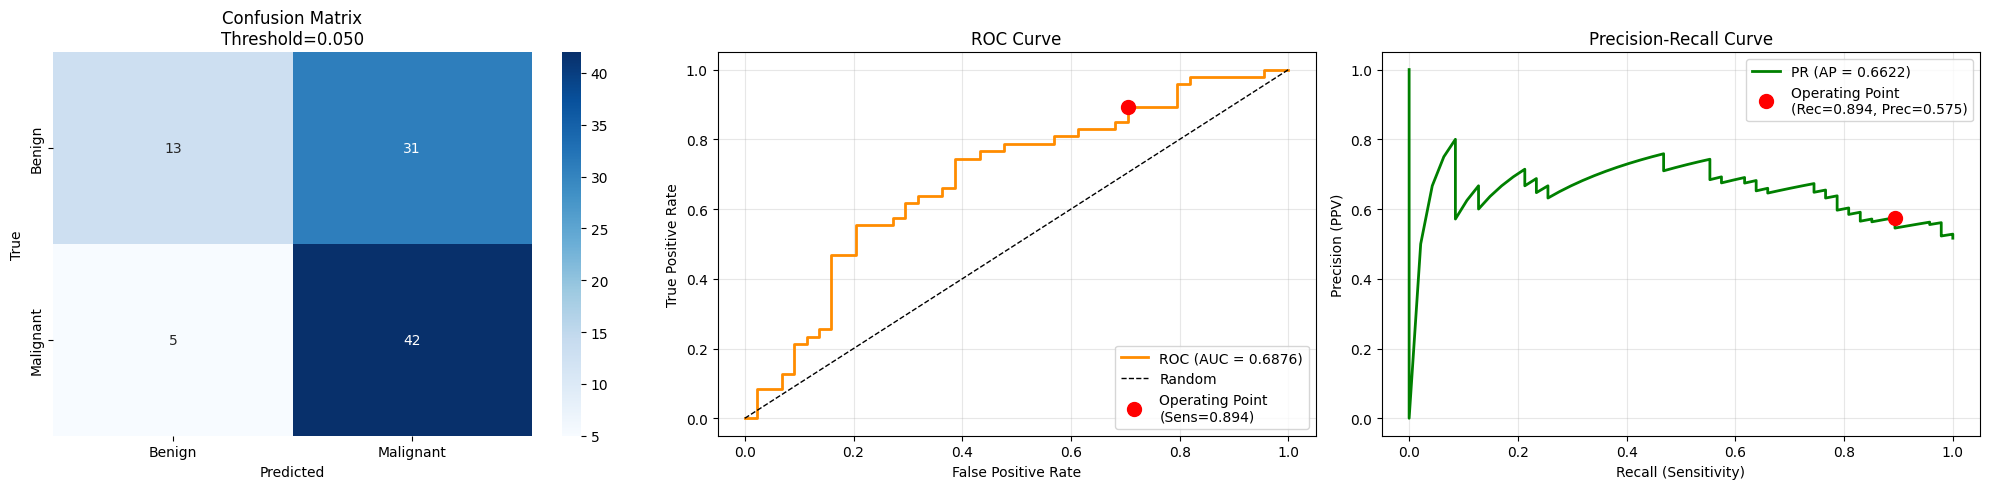

In [57]:
print(f"\nEnsemble of {K_FOLDS} folds — evaluating on held-out test set...")

# Average probabilities across folds
tiny_ensemble_probs = np.mean(tiny_fold_test_probs, axis=0)

tiny_test_metrics = binary_model_evaluation(
    test_labels, tiny_ensemble_probs, CLASS_NAMES,
    title="SwinV2-Tiny (patch4-window8-256) Linear Probe — Ensemble Test",
    min_sensitivity=MIN_SENSITIVITY_TARGET
)

## 14. Comparison: Base vs Tiny

In [58]:
# Compile comparison table
comparison_data = {
    'Model': ['SwinV2-Base', 'SwinV2-Tiny'],
    'Embed Dim': [embed_dim_base, embed_dim_tiny],
    'Threshold': [base_test_metrics['threshold'], tiny_test_metrics['threshold']],
    'Accuracy': [base_test_metrics['accuracy'], tiny_test_metrics['accuracy']],
    'Sensitivity': [base_test_metrics['sensitivity'], tiny_test_metrics['sensitivity']],
    'Specificity': [base_test_metrics['specificity'], tiny_test_metrics['specificity']],
    'F1': [base_test_metrics['f1'], tiny_test_metrics['f1']],
    'F2': [base_test_metrics['f2'], tiny_test_metrics['f2']],
    'AUC-ROC': [base_test_metrics['auc_roc'], tiny_test_metrics['auc_roc']],
    'AUC-PR': [base_test_metrics['auc_pr'], tiny_test_metrics['auc_pr']],
}

comparison_df = pd.DataFrame(comparison_data)

print(f"\n{'='*90}")
print("  SwinV2 Linear Probe — Test Set Comparison (Ensemble of 5 Folds)")
print(f"{'='*90}")
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f"{'='*90}")


  SwinV2 Linear Probe — Test Set Comparison (Ensemble of 5 Folds)
      Model  Embed Dim  Threshold  Accuracy  Sensitivity  Specificity     F1     F2  AUC-ROC  AUC-PR
SwinV2-Base        768     0.0500    0.5604       0.9362       0.1591 0.6875 0.8178   0.5832  0.5908
SwinV2-Tiny        768     0.0500    0.6044       0.8936       0.2955 0.7000 0.8046   0.6876  0.6622


## 15. Visualize Comparison

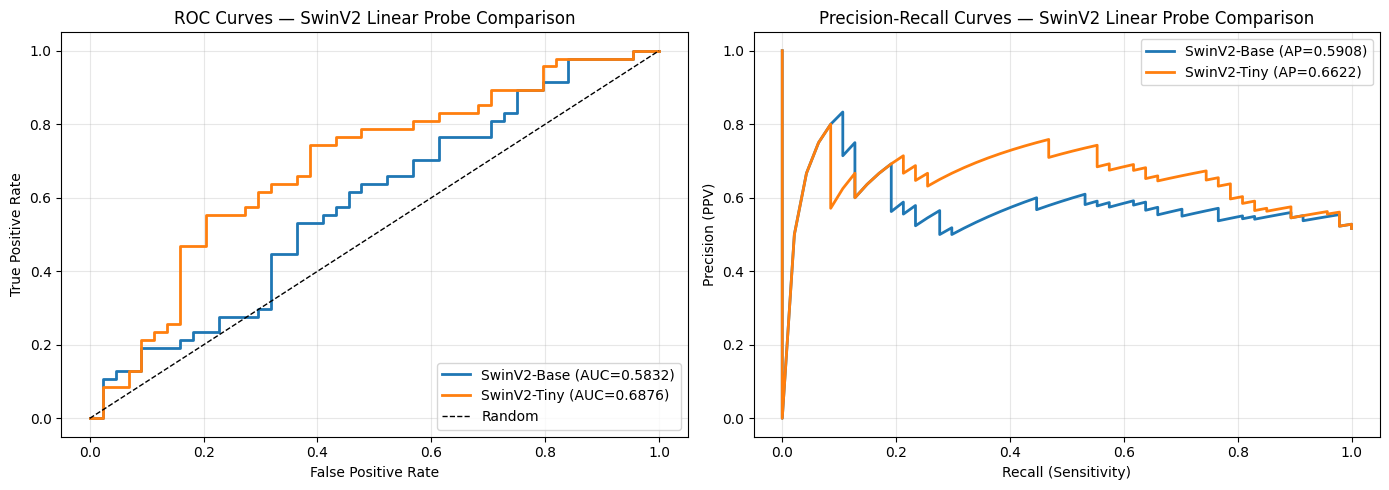

In [59]:
# Side-by-side ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
fpr_base, tpr_base, _ = roc_curve(test_labels, base_ensemble_probs)
fpr_tiny, tpr_tiny, _ = roc_curve(test_labels, tiny_ensemble_probs)

axes[0].plot(fpr_base, tpr_base, lw=2, label=f"SwinV2-Base (AUC={base_test_metrics['auc_roc']:.4f})")
axes[0].plot(fpr_tiny, tpr_tiny, lw=2, label=f"SwinV2-Tiny (AUC={tiny_test_metrics['auc_roc']:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — SwinV2 Linear Probe Comparison")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# PR Curves
prec_base, rec_base, _ = precision_recall_curve(test_labels, base_ensemble_probs)
prec_tiny, rec_tiny, _ = precision_recall_curve(test_labels, tiny_ensemble_probs)

axes[1].plot(rec_base, prec_base, lw=2, label=f"SwinV2-Base (AP={base_test_metrics['auc_pr']:.4f})")
axes[1].plot(rec_tiny, prec_tiny, lw=2, label=f"SwinV2-Tiny (AP={tiny_test_metrics['auc_pr']:.4f})")
axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision (PPV)")
axes[1].set_title("Precision-Recall Curves — SwinV2 Linear Probe Comparison")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 16. Results Summary

In [60]:
print("\n" + "="*70)
print("  SWINV2 LINEAR PROBE RESULTS SUMMARY")
print("="*70)
print(f"\nInput Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Protocol: {K_FOLDS}-Fold CV, Ensemble by averaging probabilities")
print(f"Classifier: LogisticRegression(max_iter={LR_MAX_ITER}, C={LR_C}, class_weight='{LR_CLASS_WEIGHT}')")
print(f"Min Sensitivity Target: {MIN_SENSITIVITY_TARGET*100:.0f}%")
print("\n" + "-"*70)
print("TEST SET PERFORMANCE (Ensemble):")
print("-"*70)

for name, metrics in [("SwinV2-Base", base_test_metrics), ("SwinV2-Tiny", tiny_test_metrics)]:
    sens_check = "✓" if metrics['sensitivity'] >= MIN_SENSITIVITY_TARGET else "✗"
    print(f"\n{name}:")
    print(f"  Threshold:   {metrics['threshold']:.3f}")
    print(f"  Accuracy:    {metrics['accuracy']:.4f}")
    print(f"  Sensitivity: {metrics['sensitivity']:.4f} {sens_check}")
    print(f"  Specificity: {metrics['specificity']:.4f}")
    print(f"  F1 Score:    {metrics['f1']:.4f}")
    print(f"  AUC-ROC:     {metrics['auc_roc']:.4f}")

# Determine best model
if base_test_metrics['auc_roc'] > tiny_test_metrics['auc_roc']:
    best_model = "SwinV2-Base"
    best_auc = base_test_metrics['auc_roc']
else:
    best_model = "SwinV2-Tiny"
    best_auc = tiny_test_metrics['auc_roc']

print("\n" + "="*70)
print(f"  Best Model by AUC-ROC: {best_model} ({best_auc:.4f})")
print("="*70)


  SWINV2 LINEAR PROBE RESULTS SUMMARY

Input Size: 256x256
Protocol: 5-Fold CV, Ensemble by averaging probabilities
Classifier: LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')
Min Sensitivity Target: 95%

----------------------------------------------------------------------
TEST SET PERFORMANCE (Ensemble):
----------------------------------------------------------------------

SwinV2-Base:
  Threshold:   0.050
  Accuracy:    0.5604
  Sensitivity: 0.9362 ✗
  Specificity: 0.1591
  F1 Score:    0.6875
  AUC-ROC:     0.5832

SwinV2-Tiny:
  Threshold:   0.050
  Accuracy:    0.6044
  Sensitivity: 0.8936 ✗
  Specificity: 0.2955
  F1 Score:    0.7000
  AUC-ROC:     0.6876

  Best Model by AUC-ROC: SwinV2-Tiny (0.6876)
